# Numerical validation of the singular limit asymptotics

This notebook follows the numerical section of the paper in mathematical order. We first state the nonlinear boundary-value problem and its finite-element discretization, then compare the computations with four predictions: selection of a discontinuous boundary trace, harmonic selection in the interior, logarithmic energy growth, and the need to resolve an order-$\kappa$ layer near each cathode--anode junction.

The computations are consistency checks for the asymptotic analysis; they are not a finite-element convergence theorem. By default the notebook uses the certified tables and figures included with the project, so it runs quickly. Set `RECOMPUTE = True` only when a complete, potentially long recomputation is intended.

In [1]:
from scripts.notebook_helpers import (
    baseline_parameter_table, benchmark_table, choose_source,
    corrugated_table, exact_constant_table, mesh_comparison_table,
    plot_single_junction_traces, practical_parameter_table, practical_summary,
    recompute_all, regression_table, show_figure, show_table, single_convergence_table,
    single_trace_diagnostics,
)

RECOMPUTE = False
SOURCE = choose_source(RECOMPUTE)

In [2]:
if RECOMPUTE:
    recompute_all()

## 1. The nonlinear electrochemical problem

Let $\Omega\subset\mathbb{R}^2$ have cathodic and anodic reactive parts $\Gamma_c$ and $\Gamma_a$, and let $\Gamma_N$ be the insulated remainder. For conductivity parameter $\kappa>0$, the potential $\phi_\kappa$ satisfies

$$
-\Delta\phi_\kappa=0 \quad\text{in }\Omega,\qquad
\partial_\nu\phi_\kappa=0 \quad\text{on }\Gamma_N,
$$
$$
\partial_\nu\phi_\kappa=-\frac{i_c(\phi_\kappa)}{\kappa} \quad\text{on }\Gamma_c,\qquad
\partial_\nu\phi_\kappa=-\frac{i_a(\phi_\kappa)}{\kappa} \quad\text{on }\Gamma_a.
$$

The Butler--Volmer laws are

$$
i_c(\phi)=i_{c,0}\!\left(e^{C_1(\phi-\phi_c)}-e^{-C_2(\phi-\phi_c)}\right),\qquad
i_a(\phi)=i_{a,0}\!\left(e^{A_2(\phi-\phi_a)}-e^{-A_1(\phi-\phi_a)}\right).
$$

Thus $i_c(\phi_c)=0$ and $i_a(\phi_a)=0$. As $\kappa$ decreases, the factor $1/\kappa$ forces the reactive trace toward the two different equilibrium potentials.

In [3]:
show_table(baseline_parameter_table())

| symbol | value | role |
| --- | --- | --- |
| $L_x$ | 0.02 m | rectangle length |
| $L_y$ | 0.01 m | rectangle height |
| $\phi_c$ | 0.2 | cathodic equilibrium potential |
| $\phi_a$ | -0.2 | anodic equilibrium potential |
| $i_{c,0}$ | $3.0\times10^{-4}$ | cathodic exchange-current scale |
| $i_{a,0}$ | $3.0\times10^{-2}$ | anodic exchange-current scale |
| $C_1=A_2$ | 83.13 | positive exponential slopes |
| $C_2=A_1$ | 35.63 | negative exponential slopes |

### Variational and finite-element formulation

Let $I_c'=i_c$ and $I_a'=i_a$, with additive constants chosen so the primitives are nonnegative. The solution minimizes

$$
J_\kappa(v)=\frac12\int_\Omega |\nabla v|^2\,dx
+\frac1\kappa\left(\int_{\Gamma_c} I_c(v)\,ds+\int_{\Gamma_a} I_a(v)\,ds\right).
$$

On a triangular mesh we use the conforming piecewise-linear space $V_h$. The discrete minimizer $\phi_{\kappa,h}\in V_h$ is equivalently characterized by

$$
\int_\Omega\nabla\phi_{\kappa,h}\cdot\nabla v_h\,dx
+\frac1\kappa\int_{\Gamma_c}i_c(\phi_{\kappa,h})v_h\,ds
+\frac1\kappa\int_{\Gamma_a}i_a(\phi_{\kappa,h})v_h\,ds=0
\quad (v_h\in V_h).
$$

The Dirichlet energy is assembled exactly on each triangle and the nonlinear edge integrals use four-point Gauss--Legendre quadrature. Strict convexity gives a unique discrete minimizer.

## 2. What the singular-limit theory predicts

On the reactive boundary define the limiting step trace

$$
\Phi_0=\phi_c\quad\text{on }\Gamma_c,\qquad
\Phi_0=\phi_a\quad\text{on }\Gamma_a.
$$

Let $u_0$ be its mixed harmonic extension: $u_0=\Phi_0$ on the reactive boundary and $\partial_\nu u_0=0$ on $\Gamma_N$. Although $\Phi_0$ jumps where cathode and anode meet, $u_0$ is the selected bulk limit away from those junctions. For $s<1/2$, a compact set $K\Subset\Omega$, and any fixed derivative order $m$, the estimates tested numerically are

$$
\|\phi_\kappa-\Phi_0\|_{L^2(\Gamma_c\cup\Gamma_a)}^2
\le C\kappa|\log\kappa|,
$$
$$
\|\phi_\kappa-\Phi_0\|_{H^s}
\le C_s\kappa^{1/2-s}|\log\kappa|^{1/2},\qquad
\|\phi_\kappa-u_0\|_{C^m(K)}
\le C_{K,m}(\kappa|\log\kappa|)^{1/2}.
$$

If $N$ is the number of smooth cathode--anode junctions, then

$$
J_\kappa(\phi_\kappa)=C_N|\log\kappa|+O(\log|\log\kappa|),\qquad
C_N=\frac{N(\phi_c-\phi_a)^2}{2\pi}.
$$

Accordingly, the main diagnostics are the boundary error divided by $\kappa|\log\kappa|$, the interior error against the same-mesh harmonic reference, and the energy ratio $R_E(\kappa)=J_{\kappa,h}/(C_N|\log\kappa|)$, whose predicted limit is one.

### Continuation and reliability of a data point

The nonlinear systems are solved by damped Newton continuation from $\kappa=1$ downward; an L-BFGS-B solve is used only if Newton stagnates. A row is **certified** when

$$
\|\nabla J_{\kappa,h}(\phi_{\kappa,h})\|_{\ell^\infty}
\le 10^{-9}\max\{1,\|\nabla J_{\kappa,h}(\phi_{\kappa,h}^{(0)})\|_{\ell^\infty}\}.
$$

For an energy-ratio plot, a certified row is retained as **admissible** only if its nodal values also remain in $[\phi_a,\phi_c]$ up to $10^{-8}$ and the safety clamp on exponential arguments is inactive. This is why the smallest attempted value of $\kappa$ is not automatically the strongest evidence.

## 3. Benchmark geometries

The single-junction problem uses $\Omega=[0,L_x]\times[0,L_y]$, with the bottom half cathodic, the other half anodic, and zero flux on the remaining three sides. Its interior diagnostic is measured on

$$
K=[0.25L_x,0.75L_x]\times[0.25L_y,0.75L_y].
$$

The rectangular multi-junction problem has four alternating equal intervals, hence $N=3$. The nonrectangular tests use

$$
\Omega_{\rm cor}=\{(x,y):0<x<L_x,\ 0<y<H(x)\},
\quad H(x)=L_y\left(1+0.22\sin\frac{2\pi x}{L_x}
+0.10\sin\left(\frac{4\pi x}{L_x}+0.5\right)\right).
$$

Their bottom-boundary junctions are at $0.18,0.39,0.60,0.81$ times $L_x$ for $N=4$, and at $0.12,0.27,0.40,0.55,0.70,0.84$ times $L_x$ for $N=6$. The junctions remain smooth flat-boundary points, separated from the insulated boundary, so the local mechanism determining $C_N$ is unchanged. The corrugated stress tests use balanced kinetics; the practical-parameter experiment is identified separately below.

In [4]:
show_table(benchmark_table(SOURCE))

| benchmark | geometry | junctions N | physics | h_min | nodes | triangles |
| --- | --- | --- | --- | --- | --- | --- |
| single rectangle | rectangle | 1 | baseline | 2.000e-08 | 9730 | 19044 |
| multi rectangle | rectangle | 3 | baseline | 5.000e-07 | 15045 | 29400 |
| corrugated four-junction | corrugated top | 4 | balanced stress test | 3.000e-07 | 22464 | 43990 |
| corrugated six-junction | corrugated top | 6 | balanced stress test | 2.000e-08 | 57330 | 112884 |

## 4. A small worked example: the bottom trace

Before examining the full asymptotic study, compare two single-junction solutions on the same graded mesh. At $\kappa=10^{-2}$ the reactive transition is broad. At $\kappa=10^{-4}$ it is visibly sharper and closer to the limiting step $\Phi_0$. The included-mode plot below uses boundary nodes sampled from the actual finite-element solution archives, not an analytic surrogate.

#### Single-junction bottom trace

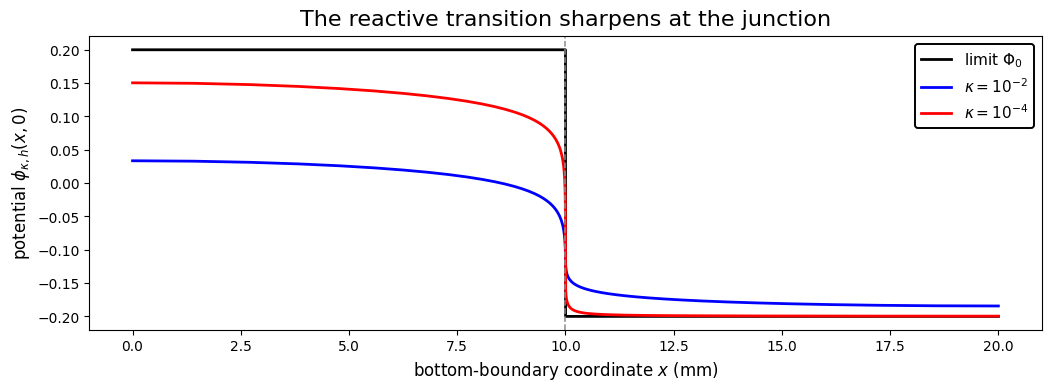

In [5]:
plot_single_junction_traces(SOURCE)

In [6]:
show_table(single_trace_diagnostics(SOURCE))

| $\kappa$ | nodes | nonlinear iterations | $\ell^\infty$ residual |
| --- | --- | --- | --- |
| 0.01 | 9730 | 7 | 2.758e-12 |
| 1.000e-04 | 9730 | 6 | 2.746e-12 |

Both rows satisfy the residual certificate. The transition narrows at the only point where the two equilibrium values meet, while the trace away from that point moves toward $\phi_c$ or $\phi_a$. This localized sharpening is the numerical signature that motivates junction grading.

## 5. Single-junction boundary and interior selection

The first full experiment follows the single-junction solution through decreasing conductivities. The three surfaces below correspond to $\kappa=10^{-3},10^{-5},10^{-7}$. The boundary layer steepens, but away from the junction the bulk sheet approaches the mixed harmonic extension.

In [7]:
show_figure("kappa_evolution_3d_single", SOURCE, height=620)
show_table(single_convergence_table(SOURCE))

#### Single-junction evolution

| $\kappa$ | boundary $L^2$ error squared | interior $L^2(K)$ error | $\ell^\infty$ residual |
| --- | --- | --- | --- |
| 1.000e-04 | 5.126e-05 | 2.596e-04 | 2.746e-12 |
| 1.000e-05 | 6.547e-06 | 7.126e-05 | 3.137e-12 |
| 1.000e-06 | 6.599e-07 | 1.113e-05 | 3.012e-12 |
| 4.000e-07 | 2.643e-07 | 5.067e-06 | 4.863e-10 |
| 2.000e-07 | 1.322e-07 | 2.765e-06 | 6.005e-11 |
| 1.300e-07 | 8.593e-08 | 1.891e-06 | 2.496e-12 |

In [8]:
show_figure("theorem_dashboard", SOURCE)
show_table(regression_table(SOURCE))

#### Boundary and interior convergence

| diagnostic | observed slope | 95% CI low | 95% CI high | reference slope |
| --- | --- | --- | --- | --- |
| boundary $L^2$ error squared | 1.0646 | 1.05082 | 1.07811 | 1 |
| interior $L^2(K)$ error squared | 1.68031 | 1.61507 | 1.81233 | 1 |
| interior $C^0(K)$ error | 0.805259 | 0.772918 | 0.878846 | 0.5 |
| interior $C^1(K)$ error | 0.739399 | 0.701215 | 0.83725 | 0.5 |
| energy-ratio remainder | 1.66141 | 1.65827 | 1.66401 | 1 |

The fitted slope $1.065$ for the squared boundary $L^2$ error is close to the reference slope one, consistent with an error of order $\kappa|\log\kappa|$. The sampled $C^0(K)$ and $C^1(K)$ slopes are about $0.81$ and $0.74$ in this finite window. Faster observed decay than an upper bound is consistent with the theorem but does not sharpen it. Bootstrap intervals quantify regression variability only; they do not include mesh bias or uncertainty from not yet reaching the asymptotic regime.

## 6. The logarithmic energy coefficient

A smoothed boundary jump has a logarithmic $H^{1/2}$ cost. Near a smooth junction its leading half-plane contribution is $(\phi_c-\phi_a)^2/(2\pi)$; contributions from separated junctions add. To keep spatial error tied to the singular scale, the refinement study uses

$$
h_{\min}=\max\{10^{-8},0.05\kappa\}.
$$

The table compares $N=1$ and $N=3$. The decisive column is $R_E(\kappa)$: the theory predicts convergence to one as $\kappa\to0$.

In [9]:
show_table(exact_constant_table(SOURCE))

| junctions N | $\kappa$ | $h_{\min}/\kappa$ | nodes | $C_N$ | $R_E(\kappa)$ | $\ell^\infty$ residual |
| --- | --- | --- | --- | --- | --- | --- |
| 1 | 1.000e-04 | 0.05 | 2701 | 0.0254648 | 0.523017 | 1.298e-14 |
| 1 | 1.000e-05 | 0.05 | 5151 | 0.0254648 | 0.614122 | 1.213e-13 |
| 1 | 1.000e-06 | 0.05 | 8385 | 0.0254648 | 0.678654 | 1.114e-12 |
| 1 | 1.300e-07 | 0.0769231 | 11175 | 0.0254648 | 0.730306 | 6.608e-08 |
| 3 | 1.000e-04 | 0.05 | 7881 | 0.0763944 | 0.423073 | 1.353e-14 |
| 3 | 1.000e-05 | 0.05 | 15045 | 0.0763944 | 0.524247 | 8.279e-11 |
| 3 | 1.000e-06 | 0.05 | 24635 | 0.0763944 | 0.604568 | 4.345e-11 |
| 3 | 1.300e-07 | 0.0769231 | 32775 | 0.0763944 | 0.665807 | 1.552e-12 |

The ratios increase as $\kappa$ decreases, but the finite windows are not equally asymptotic. In particular, the three-junction rectangle reaches only about $0.666$ at $1.3\times10^{-7}$; this is movement toward the predicted constant, not a convincing plateau. The residual and range columns are therefore as important as the normalized energy itself.

## 7. Corrugated geometry: locality of the junction cost

Changing the insulated top boundary tests whether the leading coefficient is local to the reactive junctions. For the six-junction domain, the left panel checks the same boundary scale as before and the right panel shows $R_E(\kappa)$. Only certified, range-preserving rows with inactive exponential clamping are used.

In [10]:
show_figure("corrugated_six_junction_diagnostics", SOURCE)
show_table(corrugated_table(SOURCE))

#### Corrugated six-junction diagnostics

| $\kappa$ | boundary $L^2$ error squared | $R_E(\kappa)$ | $\ell^\infty$ residual |
| --- | --- | --- | --- |
| 3.000e-07 | 9.060e-08 | 0.9425 | 8.216e-13 |
| 4.000e-07 | 1.218e-07 | 0.890319 | 7.096e-13 |
| 1.000e-06 | 3.085e-07 | 0.769829 | 6.751e-13 |
| 3.000e-06 | 9.279e-07 | 0.682282 | 6.676e-13 |
| 5.000e-06 | 1.545e-06 | 0.652648 | 1.232e-11 |
| 1.000e-05 | 3.080e-06 | 0.617786 | 6.023e-13 |

The smallest admissible six-junction point is $\kappa=3\times10^{-7}$, where $R_E\approx0.943$. Smaller attempted points that fail the residual or range test are deliberately excluded. Together with the four-junction ratio near $0.938$, this supports geometric locality over the certified finite window without claiming that the limiting regime has been fully reached.

## 8. Robustness under practical parameter ratios

The next experiment replaces the baseline kinetics by ratios fitted for one-layer ZrO$_2$-coated stainless steel in NaCl. A common exchange-current magnitude is absorbed into the nondimensional conductivity, leaving the reported ratio. These runs are robustness checks, not material calibration.

In [11]:
show_table(practical_parameter_table(SOURCE))

| symbol | value | role |
| --- | --- | --- |
| $\phi_a$ | -0.58 | anodic equilibrium potential |
| $\phi_c$ | -0.07 | cathodic equilibrium potential |
| $i_{a,0}/i_{c,0}$ | 1.01677 | exchange-current ratio |
| $A_1=A_2$ | 9.47566 | anodic exponential slopes |
| $C_1=C_2$ | 12.7215 | cathodic exponential slopes |

In [12]:
show_figure("practical_stainless_zro2_corrugated_diagnostics", SOURCE, height=560)
show_table(practical_summary(SOURCE))

#### Practical-parameter robustness

| junctions N | smallest retained kappa | energy ratio at retained point | next excluded kappa | next residual |
| --- | --- | --- | --- | --- |
| 4 | 5.000e-07 | 0.977887 | 3.000e-07 | 0.126954 |
| 6 | 5.000e-07 | 0.949881 | 3.000e-07 | 0.126341 |

At the smallest retained conductivity, the energy ratios are about $0.978$ for $N=4$ and $0.950$ for $N=6$. The next smaller point is excluded by the residual certificate. The first two panels also show convergence in $L^2$ and the subcritical trace space $H^{1/4}$, so the robustness check addresses more than the energy normalization alone.

## 9. Why the smallest mesh scale should follow $\kappa$

The trace changes over an order-$\kappa$ distance near each junction. A uniform mesh spends most of its nodes away from that layer, whereas a junction-graded mesh places its smallest elements where the singular cost is generated. The quantitative comparison uses:

- a uniform mesh with approximately the same node count $N_h$ as the graded mesh;
- a uniform mesh with about $4N_h$ nodes;
- a locally graded mesh with $h_{\min}=0.25\kappa$;
- an over-resolved graded reference with $h_*=0.05\kappa$.

Errors are measured on the reactive boundary in $L^2$ and $H^{1/4}$ and in the interior rectangle $K$ in $L^2$.

In [13]:
show_figure("mesh_strategy_triptych", SOURCE)

#### Meshes near the reactive junctions

In [14]:
show_figure("mesh_comparison_refined_single", SOURCE)
show_table(mesh_comparison_table(SOURCE, kappa=1.0e-5))

#### Quantitative mesh comparison

| mesh | nodes | boundary $L^2$ error | boundary $H^{1/4}$ error | interior $L^2(K)$ error | $R_E(\kappa)$ |
| --- | --- | --- | --- | --- | --- |
| graded (N) | 930 | 4.720e-06 | 0.00715262 | 1.914e-06 | 0.721042 |
| uniform (N) | 861 | 0.00264196 | 0.0828179 | 2.806e-06 | 18.2659 |
| uniform (4N) | 3655 | 0.00166413 | 0.0644803 | 4.438e-06 | 8.96087 |

At $\kappa=10^{-5}$ the graded mesh uses $930$ nodes and has boundary error about $5\times10^{-6}$. The $4N_h$ uniform mesh uses $3655$ nodes yet remains near $1.7\times10^{-3}$. The unresolved uniform meshes also distort the energy ratio and fail the residual certificate in this comparison. The important resource is therefore resolution near the junction, not merely a larger global node count.

## 10. Conclusions and limitations

The experiments consistently show four features: the reactive trace approaches the discontinuous equilibrium profile; the interior selects its mixed harmonic extension; each smooth cathode--anode junction contributes the predicted local logarithmic energy cost; and meshes must resolve a scale comparable with $\kappa$ near those junctions.